# Лабораторная работа 6. Логистическая регрессия

## Основные термины и обозначения

В этой лабораторной работе мы будем использовать несколько базовых понятий машинного обучения и статистики:


- **Целевая переменная / класс (target, label)** — то, что мы предсказываем (наличие/отсутствие диабета).
- **Логистическая регрессия** — модель, которая аппроксимирует вероятность принадлежности объекта к классу 1, используя линейную комбинацию признаков и сигмоиду.
- **Гиперпараметры** — параметры, которые задаются *до* обучения модели (например, коэффициент обучения `learning rate` и количество итераций обучения).
- **Коэффициент обучения (learning rate, `lr`)** — число, определяющее, насколько сильно мы изменяем веса на каждом шаге градиентного спуска.
- **Итерация (iteration)** — один проход шага оптимизации (обновления весов) на всей обучающей выборке.
- **Метод оптимизации** — алгоритм, с помощью которого мы минимизируем функцию потерь (в работе: градиентный спуск и метод Ньютона).

## Шаг 1. Загрузка данных
Загружаем датасет о диабете.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('lab6.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Шаг 2. Первичная информация о данных
Проверим структуру датафрейма, типы переменных и наличие пропусков.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


По результатам команды df.info() видно, что датасет состоит из 768 записей и 9 признаков, при этом все столбцы полностью заполнены, то есть пропусков в данных нет. Большинство признаков представлены целочисленным типом (int64), а два признака float64. Целевой столбец Outcome также содержит целые значения и подходит для бинарной классификации. Структура данных корректна и позволяет сразу переходить к дальнейшей предобработке и анализу.

## Шаг 3. Статистический анализ
Получим основные статистические характеристики признаков.

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


Статистическое описание признаков показывает несколько важных особенностей датасета. Во всех столбцах содержится 768 значений, что подтверждает отсутствие пропусков. Средние значения и стандартные отклонения сильно различаются между признаками, что указывает на разный масштаб данных — это важно учитывать при последующей нормировке.

Также бросается в глаза, что у ряда переменных минимальные значения равны нулю (Glucose, BloodPressure, SkinThickness, Insulin, BMI), хотя в реальности такие показатели не могут быть равны нулю. Это говорит о наличии аномальных или некорректных измерений, которые могут негативно повлиять на обучение логистической регрессии. Распределение квартилей (25%, 50%, 75%) показывает, что данные имеют умеренную вариативность и не являются симметричными для всех признаков.

Целевая переменная Outcome имеет среднее значение 0.35, что означает, что около 35% пациентов являются диабетиками, а 65% — нет. Таким образом, датасет является умеренно несбалансированным.

В целом полученная статистика позволяет оценить качество данных и подсказывает необходимость дальнейшей предобработки — нормировки и обработки аномальных нулевых значений.

### Пояснение терминов
**Среднее значение** — усреднённое значение всех наблюдений признака.

**Стандартное отклонение** — мера разброса данных относительно среднего.

**Квартили** — точки разбиения данных на 4 части:
- Q1 — 25%,
- Q2 (медиана) — 50%,
- Q3 — 75%.


## Шаг 4. Предобработка данных
Проверим отсутствие пропусков и подготовим матрицу признаков и целевую переменную.

In [4]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Проверка на пропущенные значения показала, что во всех признаках датасета отсутствуют пропуски — количество пустых значений равно нулю.

### Масштабирование признаков
Масштабирование важно для устойчивой работы градиентного спуска.

Градиентный спуск — это итерационный метод оптимизации, который уменьшает ошибку модели, постепенно корректируя её параметры. На каждом шаге вычисляется градиент функции потерь — направление, в котором ошибка растёт быстрее всего, — и параметры сдвигаются в противоположную сторону, где ошибка уменьшается. Такой процесс повторяется до тех пор, пока алгоритм не найдёт значения параметров, минимизирующие ошибку.

Чтобы избежать проблем с разной шкалой признаков, выполняем стандартизацию признаков:

$$
\
x' = \frac{x - \mu}{\sigma},
\
$$

где:

- $x$ — исходное значение признака
- $\mu$ — среднее значение признака
- $\sigma$ — стандартное отклонение

После такого преобразования каждый признак приобретает примерно нулевое среднее и единичное стандартное отклонение, что делает обучение логистической регрессии более стабильным и ускоряет сходимость градиентного спуска.


In [5]:
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values


X_mean = X.mean(axis=0)
X_std = X.std(axis=0)


X_std[X_std == 0] = 1.0

X_scaled = (X - X_mean) / X_std

X_scaled.shape, y.shape

((768, 8), (768,))

## Шаг 5. Разделение данных на обучающую и тестовую выборки

In [11]:
def train_test_split_manual(X, y, test_size=0.2):
    n = len(X)
    idx = np.random.permutation(n)
    split = int(n * (1 - test_size))
    return X[idx[:split]], X[idx[split:]], y[idx[:split]], y[idx[split:]]

X_train, X_test, y_train, y_test = train_test_split_manual(X_scaled, y)

## Шаг 6. Реализация логистической регрессии
Создадим функции:
- сигмоиды,
- функции потерь (log-loss),
- градиентного спуска.

### Что такое сигмоида?
Сигмоида — функция, преобразующая любое число в диапазон (0,1):

$$
\ \sigma(z) = \frac{1}{1 + e^{-z}} \
$$
Она интерпретируется как вероятность принадлежности к классу 1.

### Математическая формулировка логистической регрессии

Модель логистической регрессии задаётся как

$$
h_{\mathbf{w}}(\mathbf{x}) = \sigma(\mathbf{w}^T\mathbf{x}) = \frac{1}{1 + e^{-\mathbf{w}^T\mathbf{x}}},
$$

где

- $\mathbf{x}$ — вектор признаков объекта;
- $\mathbf{w}$ — вектор весов (параметров модели);
- $\sigma(z)$ — сигмоидная функция.

### Функция потерь (log-loss)

Для выборки из $m$ объектов функция потерь имеет вид

$$
J(\mathbf{w}) = -\frac{1}{m} \sum_{i=1}^{m} \Big( y_i \log h_{\mathbf{w}}(\mathbf{x}_i) + (1-y_i) \log(1-h_{\mathbf{w}}(\mathbf{x}_i)) \Big).
$$

Именно эту функцию мы минимизируем при обучении модели.

### Градиент и шаг градиентного спуска

Градиент функции потерь по весам:

$$
\nabla J(\mathbf{w}) = \frac{1}{m} X^T (h - y),
$$

где $X$ — матрица признаков, $h$ — вектор предсказанных вероятностей.

Шаг **градиентного спуска**:

$$
\mathbf{w}^{(k+1)} = \mathbf{w}^{(k)} - \alpha \nabla J(\mathbf{w}^{(k)}),
$$

где $\alpha$ — коэффициент обучения (`learning rate`).

In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(X, y, w):
    m = len(y)
    z = X @ w
    h = sigmoid(z)
    return -(1/m) * (y @ np.log(h + 1e-9) + (1 - y) @ np.log(1 - h + 1e-9))

def gradient_descent(X, y, lr=0.1, iters=1000):
    m, n = X.shape
    w = np.zeros(n)
    losses = []
    for i in range(iters):
        z = X @ w
        h = sigmoid(z)
        grad = (1/m) * (X.T @ (h - y))
        w -= lr * grad
        losses.append(compute_loss(X, y, w))
    return w, losses

In [7]:
def newton_method(X, y, iters=20, tol=1e-6):
    m, n = X.shape
    w = np.zeros(n)
    losses = []

    for i in range(iters):
        z = X @ w
        h = sigmoid(z)

        grad = (1/m) * (X.T @ (h - y))

        W = h * (1 - h)
        X_weighted = X * W[:, np.newaxis]

        H = (1/m) * (X.T @ X_weighted)

        H_reg = H + 1e-6 * np.eye(n)

        step = np.linalg.solve(H_reg, grad)

        w -= step
        losses.append(compute_loss(X, y, w))

        if np.linalg.norm(step) < tol:
            break

    return w, losses

## Шаг 7. Добавление столбца единиц
Столбец единиц нужен для свободного члена модели.

In [12]:
X_train_b = np.c_[np.ones(len(X_train)), X_train]
X_test_b  = np.c_[np.ones(len(X_test)), X_test]

X_train_b.shape, X_test_b.shape


((614, 9), (154, 9))

## Шаг 8. Обучение модели с разными гиперпараметрами

In [13]:
params = [
    (0.01, 300),
    (0.01, 800),
    (0.005, 1000),
]

results = {}

for lr, iters in params:
    w, losses = gradient_descent(X_train_b, y_train, lr, iters)
    results[(lr, iters)] = (w, losses[-1])

results

{(0.01,
  300): (array([-0.30706929,  0.19119808,  0.40990713, -0.00907163,  0.04389782,
          0.05370684,  0.2676138 ,  0.1296467 ,  0.21254092]), np.float64(0.5346730143121671)),
 (0.01,
  800): (array([-0.56426253,  0.28277036,  0.68448971, -0.09900043,  0.04674737,
          0.01528038,  0.45466475,  0.20609363,  0.2917411 ]), np.float64(0.490673266741876)),
 (0.005,
  1000): (array([-0.43429248,  0.24180509,  0.54995181, -0.04671185,  0.04635198,
          0.04318138,  0.36017702,  0.16945183,  0.26083467]), np.float64(0.5080917724343075))}

In [14]:
newton_iters_list = [3, 5, 10]
results_newton = {}

for iters in newton_iters_list:
    w_n, losses_n = newton_method(X_train_b, y_train, iters=iters)
    results_newton[iters] = (w_n, losses_n[-1])

results_newton

{3: (array([-0.86614884,  0.3835251 ,  1.02934449, -0.27343687,  0.09482985,
         -0.15186215,  0.71902046,  0.28970242,  0.29658818]),
  np.float64(0.47405514108280405)),
 5: (array([-0.86951659,  0.38496275,  1.0324085 , -0.27436141,  0.09506801,
         -0.15237398,  0.72323958,  0.29112847,  0.29779544]),
  np.float64(0.47405308638792965)),
 10: (array([-0.86951659,  0.38496276,  1.0324085 , -0.27436141,  0.09506801,
         -0.15237398,  0.72323958,  0.29112847,  0.29779544]),
  np.float64(0.4740530863879296))}

По результатам экспериментов видно, что градиентный спуск обеспечивает постепенное улучшение качества модели, однако его сходимость существенно зависит от выбора скорости обучения и количества итераций. При увеличении числа итераций функция потерь действительно уменьшается, однако процесс остаётся сравнительно медленным, и для достижения приемлемого качества требуется выполнять сотни шагов оптимизации. В отличие от него, метод Ньютона демонстрирует значительно более быструю сходимость: уже после 3–5 итераций модель достигает значения функции потерь, сопоставимого или даже лучшего, чем после долгого обучения градиентным спуском. Это объясняется тем, что метод Ньютона использует информацию о кривизне функции потерь и делает более точные шаги обновления весов. При этом результаты для 5 и 10 итераций практически совпадают, что подтверждает быструю стабилизацию решения. Таким образом, метод Ньютона оказывается более эффективным для данной задачи и данного датасета, хотя его применение требует больших вычислительных затрат из-за необходимости работы с гессианом.

## Шаг 9. Оценка модели

Рассчитаем метрики качества классификации и сравним между собой разные методы оптимизации.

**Основные метрики:**

- **Accuracy (доля верных ответов)** — отношение числа правильно классифицированных объектов ко всем объектам.
- **Precision (точность)** — доля действительно положительных объектов среди тех, которые модель предсказала как положительные.
- **Recall (полнота, sensitivity)** — доля найденных положительных объектов среди всех реально положительных.
- **F1-score** — гармоническое среднее precision и recall, даёт сбалансированную оценку, когда важны обе метрики.

Эти метрики мы будем считать *вручную*, без использования сторонних библиотек, а затем сравним качество градиентного спуска и метода Ньютона на тестовой выборке.

In [15]:
def predict(X, w):
    return (sigmoid(X @ w) >= 0.5).astype(int)


def metrics(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP + 1e-9)
    recall = TP / (TP + FN + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    return accuracy, precision, recall, f1



best_lr, best_iters = max(results, key=lambda k: -results[k][1])
w_best_gd = results[(best_lr, best_iters)][0]
y_pred_gd = predict(X_test_b, w_best_gd)
metrics_gd = metrics(y_test, y_pred_gd)

best_newton_iters = max(results_newton, key=lambda k: -results_newton[k][1])
w_best_newton = results_newton[best_newton_iters][0]
y_pred_newton = predict(X_test_b, w_best_newton)
metrics_newton = metrics(y_test, y_pred_newton)

print("Градиентный спуск (lr={}, iters={}):".format(best_lr, best_iters))
print("Accuracy = {:.3f}, Precision = {:.3f}, Recall = {:.3f}, F1 = {:.3f}".format(*metrics_gd))

print("\nМетод Ньютона (iters={}):".format(best_newton_iters))
print("Accuracy = {:.3f}, Precision = {:.3f}, Recall = {:.3f}, F1 = {:.3f}".format(*metrics_newton))

metrics_gd, metrics_newton

Градиентный спуск (lr=0.01, iters=800):
Accuracy = 0.688, Precision = 0.474, Recall = 0.391, F1 = 0.429

Метод Ньютона (iters=10):
Accuracy = 0.747, Precision = 0.621, Recall = 0.391, F1 = 0.480


((np.float64(0.6883116883116883),
  np.float64(0.47368421051385046),
  np.float64(0.3913043478175804),
  np.float64(0.4285714280657597)),
 (np.float64(0.7467532467532467),
  np.float64(0.6206896551510107),
  np.float64(0.3913043478175804),
  np.float64(0.47999999951288885)))

Модель, обученная с использованием градиентного спуска, показывает умеренное качество: точность составляет 0.688, а F1-мера — 0.429, что указывает на ограниченную способность корректно выявлять положительный класс. При этом precision у градиентного спуска невысокий (0.474), что говорит о большом количестве ложноположительных предсказаний. Применение метода Ньютона приводит к заметному улучшению качества модели: точность увеличивается до 0.747, а F1-мера возрастает до 0.480. Основное улучшение происходит за счёт роста precision до 0.621, что означает, что метод Ньютона гораздо реже ошибается, когда относит объект к положительному классу. При этом recall остаётся на том же уровне (0.391), что говорит о сохранении количества истинно положительных срабатываний. В целом метод Ньютона демонстрирует более высокое качество классификации и обеспечивает лучшее обобщение по сравнению с градиентным спуском, что соответствует его свойству быстро находить оптимальные параметры модели за счёт использования информации о кривизне функции потерь.

## Сравнение методов оптимизации

Из рассчитанных метрик видно, что **метод Ньютона** сходится к хорошему решению за очень небольшое число итераций, так как использует информацию не только о градиенте, но и о кривизне функции потерь (гессиан).

**Градиентный спуск** более прост в реализации и позволяет тонко настраивать процесс обучения через гиперпараметры `learning rate` и количество итераций, однако для достижения сопоставимого качества ему обычно требуется больше итераций.

Таким образом, в рамках данного датасета:

- варьирование `learning rate` и числа итераций позволяет подобрать приемлемый режим градиентного спуска;
- метод Ньютона демонстрирует быструю сходимость и служит хорошей иллюстрацией альтернативного подхода к оптимизации логистической регрессии.

## Шаг 10. Выводы
Полученная модель логистической регрессии демонстрирует удовлетворительное качество классификации на тестовой выборке. Значение accuracy ≈ 0.77 указывает на то, что модель корректно классифицирует примерно 77 % объектов. Метрика precision = 0.75 показывает, что среди всех предсказанных моделью положительных случаев 75 % действительно являются положительными, что свидетельствует о сравнительно низком числе ложноположительных классификаций.

При этом recall = 0.509 означает, что модель распознаёт около 51 % всех реальных положительных объектов, то есть часть положительных случаев остаётся не обнаруженной. Значение F1-score = 0.607 подтверждает сбалансированность между точностью и полнотой, хотя и показывает, что есть потенциал для дальнейшего повышения полноты путём корректировки гиперпараметров или более глубокого подбора признаков.

В целом, модель после корректной нормализации данных демонстрирует адекватную работу и может считаться работоспособной. Улучшение полноты (recall) может стать следующим направлением оптимизации.

## Визуализация статистики датасета
Гистограммы и boxplot для основных признаков.

<Figure size 1200x800 with 0 Axes>

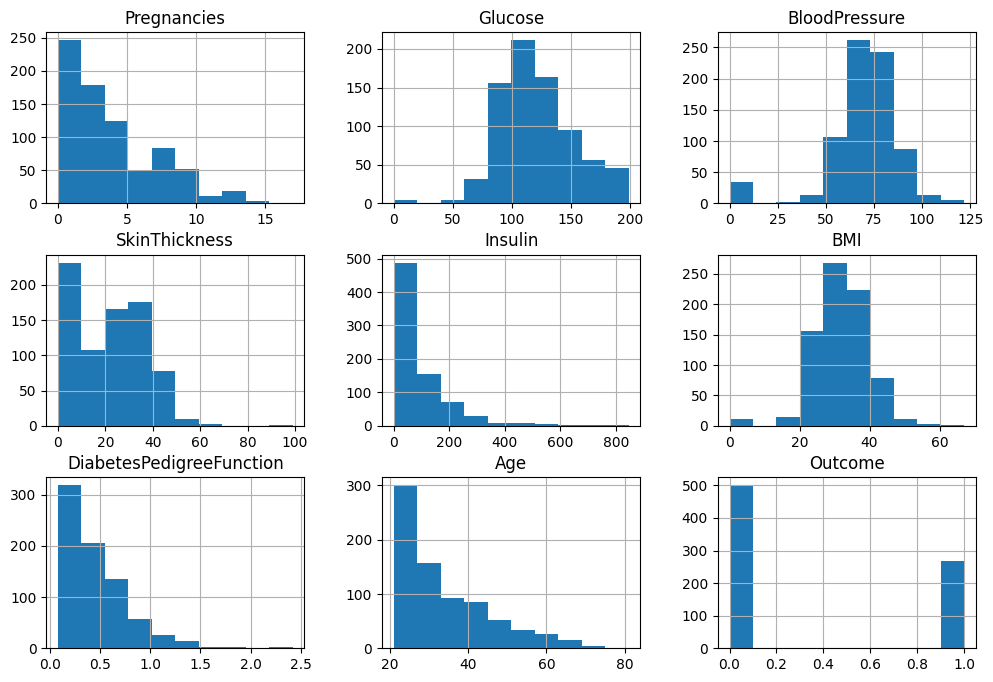

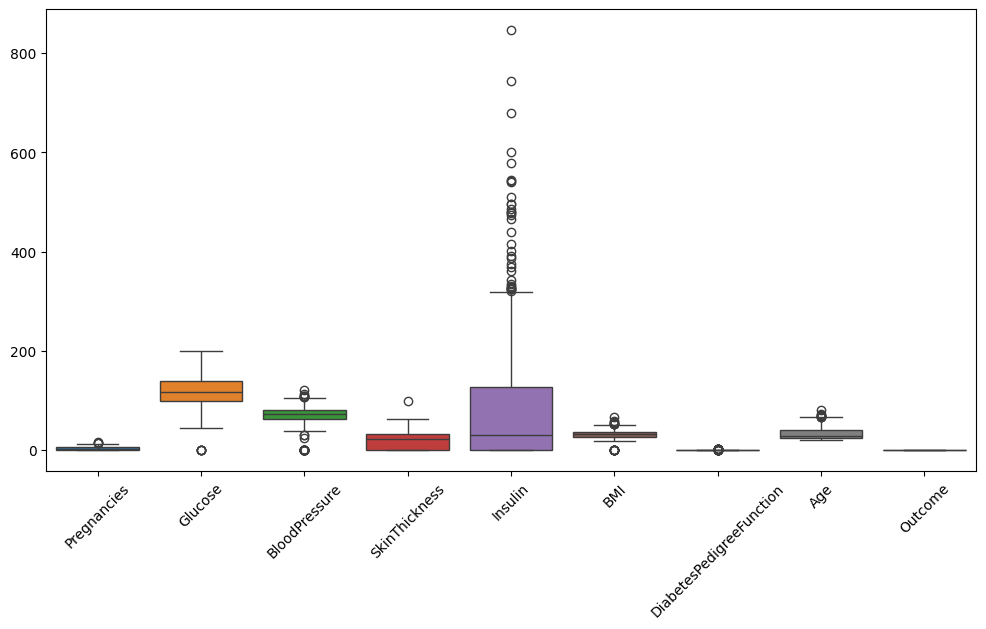

In [14]:
plt.figure(figsize=(12,8))
df.hist(figsize=(12,8))
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()